House Price Prediction

Dataset: Ames Housing — 2,930 houses, 80 features

Goal: Compare Linear Regression, Ridge, Random Forest, XGBoost

In [5]:
# ── 1. Load Data ──────────────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='darkgrid')

# load directly from GitHub — no manual download needed
url = 'https://raw.githubusercontent.com/wblakecannon/ames/master/data/housing.csv'
df  = pd.read_csv(url)

df.to_csv('/content/drive/MyDrive/housing_project/ames_housing.csv', index=False)

print(df.shape)
print(df.columns.tolist())

(2930, 83)
['Unnamed: 0', 'Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', '

In [6]:
# ── 2. Data Quality Check ─────────────────────────────────────────────────

# drop row ID columns — no predictive value
df = df.drop(columns=['Unnamed: 0', 'Order', 'PID'])

print("Shape after dropping IDs:", df.shape)
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal columns with missing: {len(missing)}")
print(f"Total missing cells: {df.isnull().sum().sum()}")

Shape after dropping IDs: (2930, 80)

=== Missing Values ===
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Total columns with missing: 27
Total missing cells: 15749


In [7]:
# ── 3. Missing Value Handling ─────────────────────────────────────────────

# these columns use NA to mean the feature doesn't exist — fill with 'None'
none_fill_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
                  'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
                  'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                  'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']
for col in none_fill_cols:
    df[col] = df[col].fillna('None')

# same logic for numeric columns — no feature means 0
zero_fill_cols = ['Garage Yr Blt', 'Garage Area', 'Garage Cars',
                  'Bsmt Full Bath', 'Bsmt Half Bath',
                  'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
                  'Mas Vnr Area']
for col in zero_fill_cols:
    df[col] = df[col].fillna(0)

# Lot Frontage is genuinely missing — fill with neighborhood median
# since nearby houses tend to have similar frontages
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)

# single missing value — fill with most common
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Missing remaining:", df.isnull().sum().sum())

# 3 houses in neighborhoods where all Lot Frontage was missing
# fall back to global median
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
print("Missing remaining after global fallback:", df.isnull().sum().sum())

Missing remaining: 3
Missing remaining after global fallback: 0


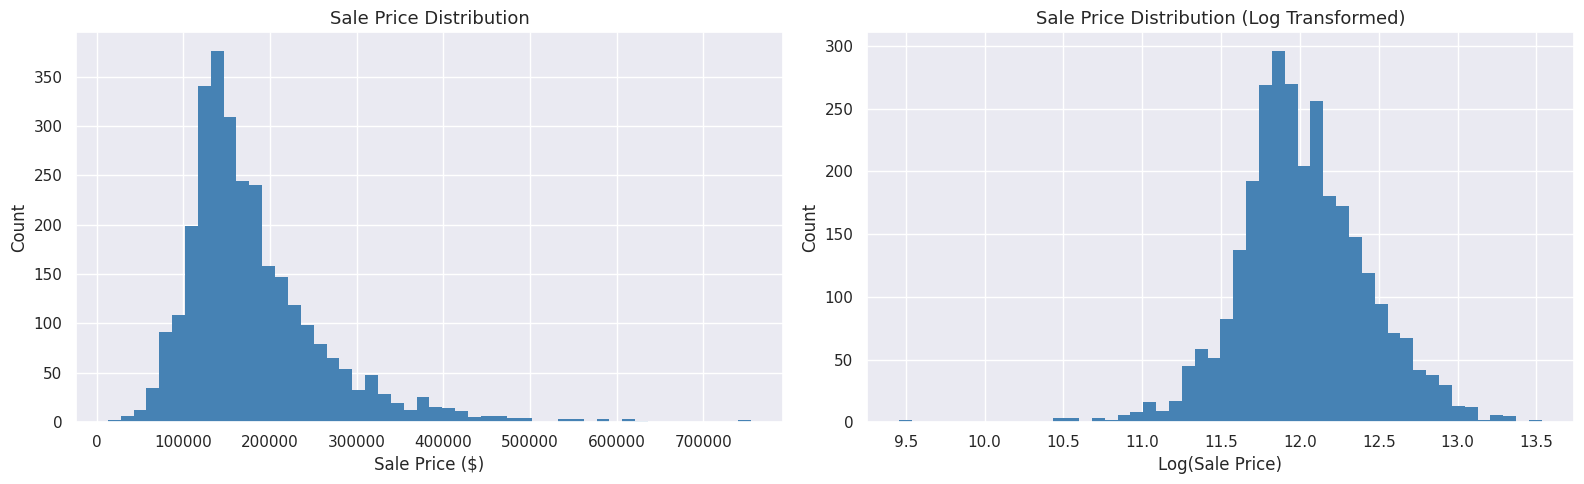

Mean:         $180,796
Median:       $160,000
Skewness:     1.744
Log Skewness: -0.015


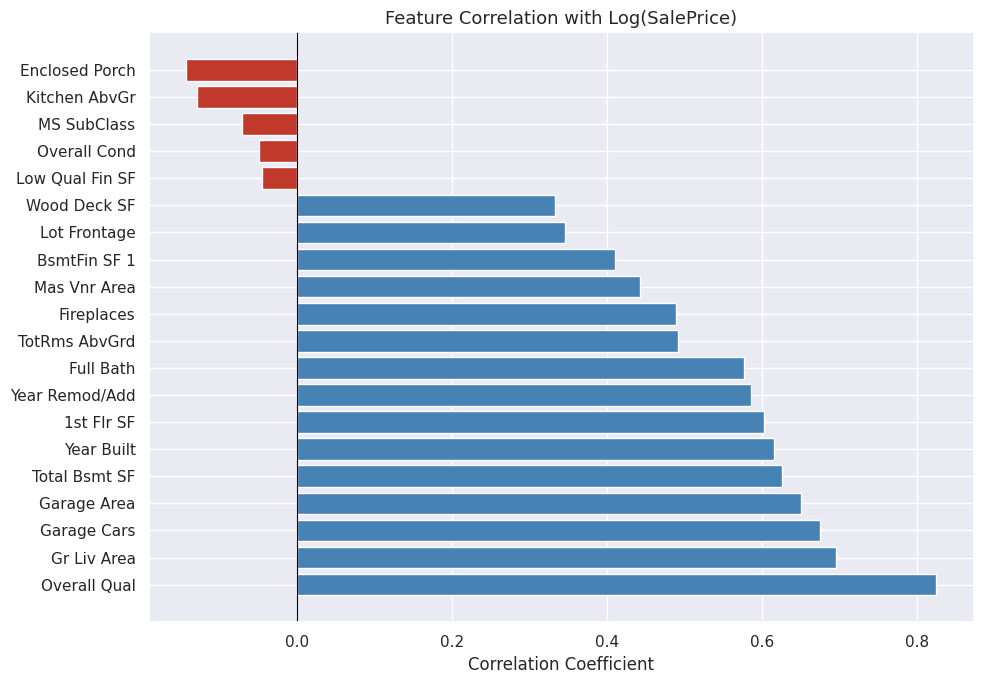

Top 15 positive correlations:
Overall Qual      0.826
Gr Liv Area       0.696
Garage Cars       0.675
Garage Area       0.651
Total Bsmt SF     0.626
Year Built        0.615
1st Flr SF        0.603
Year Remod/Add    0.586
Full Bath         0.577
TotRms AbvGrd     0.493
Fireplaces        0.489
Mas Vnr Area      0.443
BsmtFin SF 1      0.411
Lot Frontage      0.347
Wood Deck SF      0.333
dtype: float64

Top 5 negative correlations:
Low Qual Fin SF   -0.045
Overall Cond      -0.048
MS SubClass       -0.071
Kitchen AbvGr     -0.128
Enclosed Porch    -0.142
dtype: float64


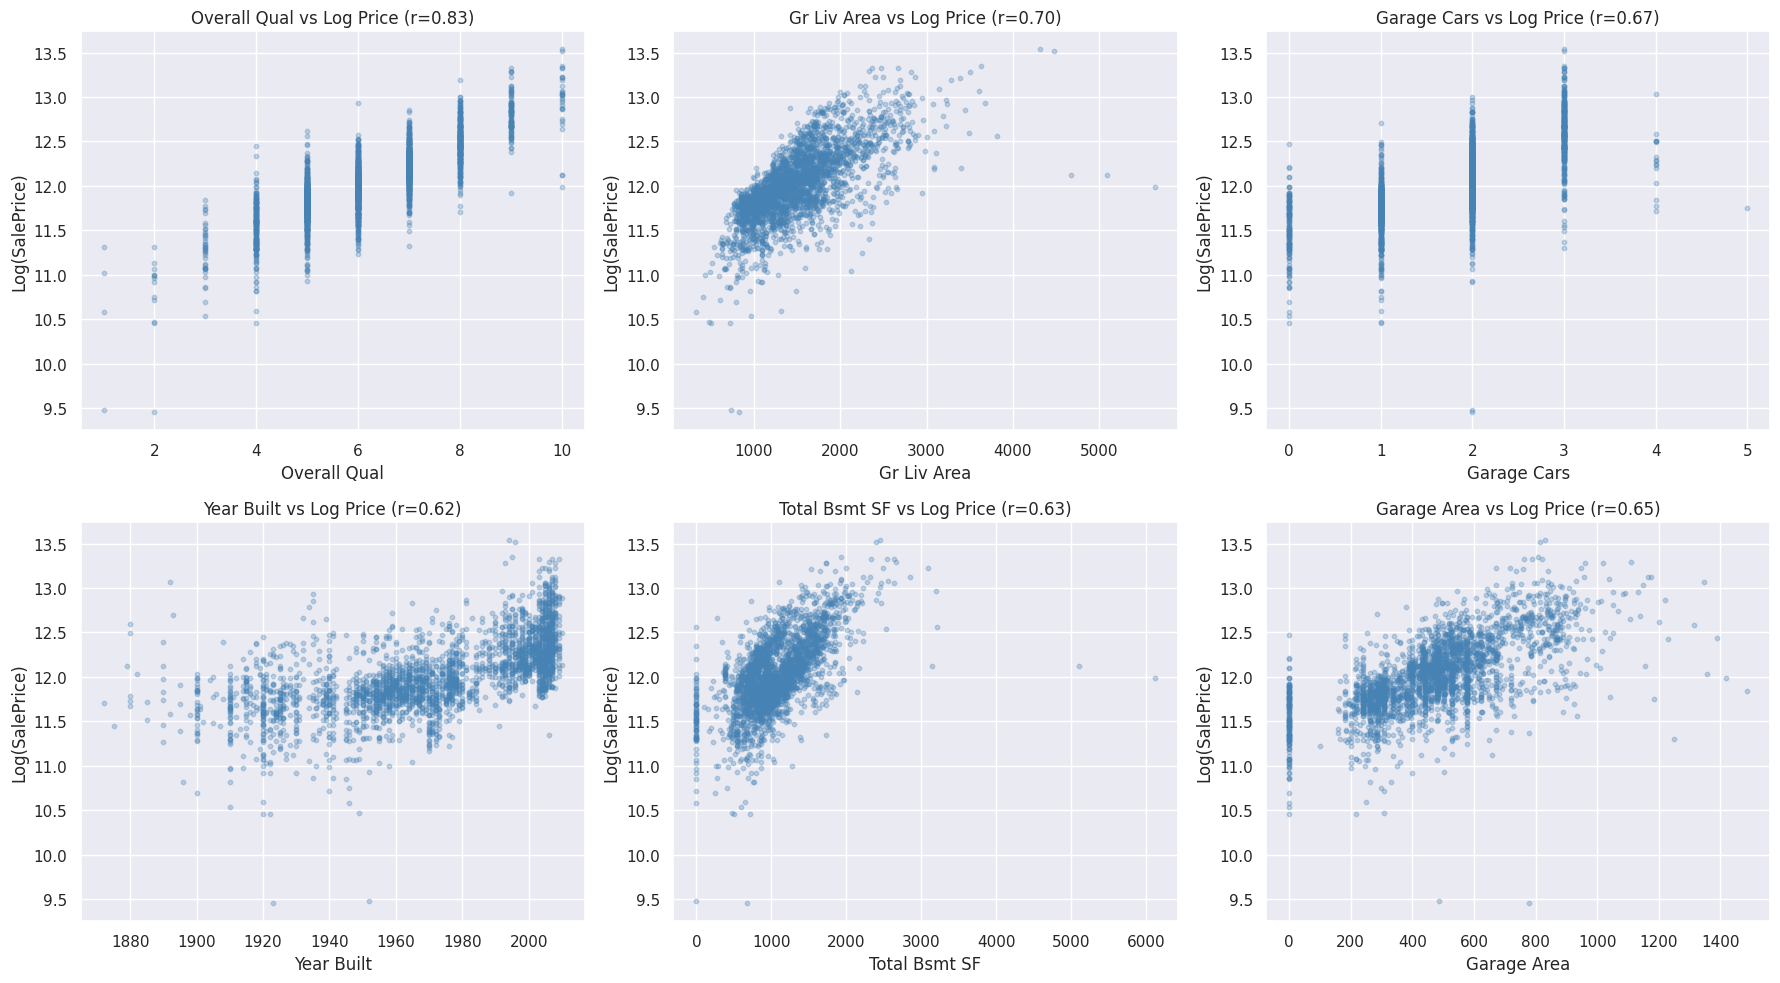

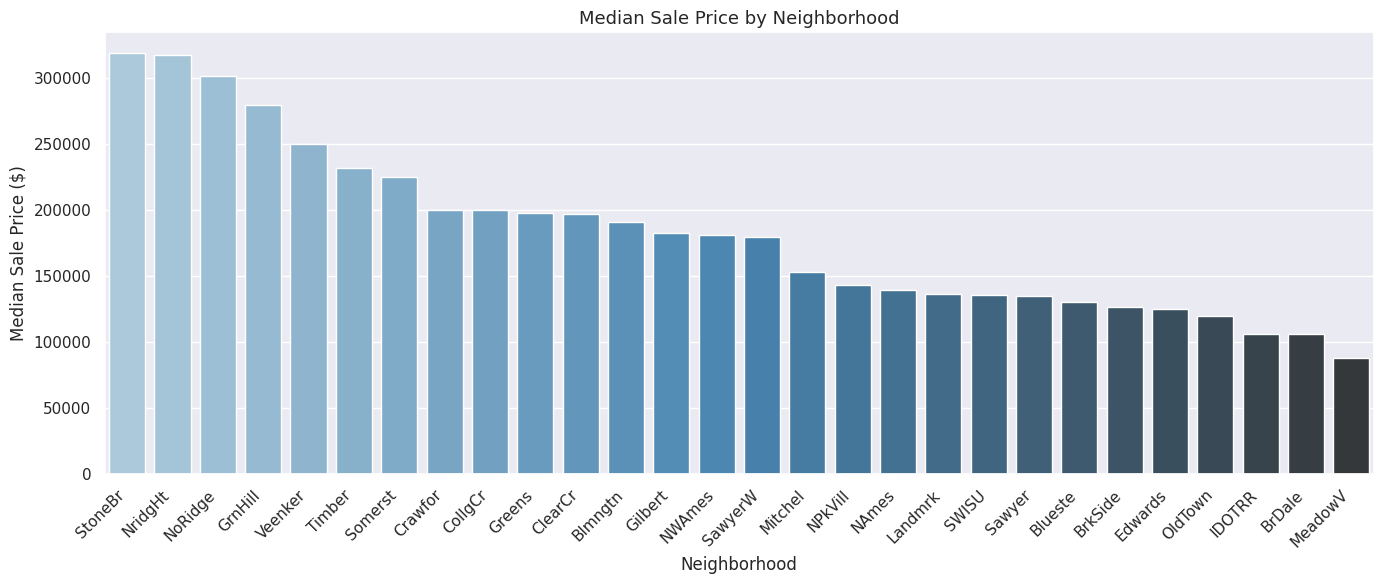

Most expensive:   Neighborhood  MedianPrice
0      StoneBr     319000.0
1      NridgHt     317750.0
2      NoRidge     302000.0
3      GrnHill     280000.0
4      Veenker     250250.0
Least expensive:    Neighborhood  MedianPrice
23      Edwards     125000.0
24      OldTown     119900.0
25       IDOTRR     106500.0
26       BrDale     106000.0
27      MeadowV      88250.0


In [9]:
# ── 4. EDA ────────────────────────────────────────────────────────────────

# raw price is right-skewed — I compare it to log-transformed to decide
# which to use as the model target
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('Sale Price Distribution', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='steelblue', edgecolor='none')
axes[1].set_title('Sale Price Distribution (Log Transformed)', fontsize=13)
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Mean:         ${df['SalePrice'].mean():,.0f}")
print(f"Median:       ${df['SalePrice'].median():,.0f}")
print(f"Skewness:     {df['SalePrice'].skew():.3f}")
print(f"Log Skewness: {np.log1p(df['SalePrice']).skew():.3f}")

# log transformation brings skewness from 1.74 to -0.015 — I use LogPrice as target
df['LogPrice'] = np.log1p(df['SalePrice'])

# correlation of all numeric features with log price
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['SalePrice', 'LogPrice']]

correlations = df[numeric_cols].corrwith(df['LogPrice']).sort_values(ascending=False)
top_corr     = pd.concat([correlations.head(15), correlations.tail(5)])

plt.figure(figsize=(10, 7))
colors = ['steelblue' if v > 0 else '#c0392b' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Log(SalePrice)', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print("Top 15 positive correlations:")
print(correlations.head(15).round(3))
print("\nTop 5 negative correlations:")
print(correlations.tail(5).round(3))

# scatter plots for the top 6 features to check linearity
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
top_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars',
                'Year Built', 'Total Bsmt SF', 'Garage Area']

for ax, col in zip(axes.flatten(), top_features):
    ax.scatter(df[col], df['LogPrice'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Log(SalePrice)')
    ax.set_title(f'{col} vs Log Price (r={df[col].corr(df["LogPrice"]):.2f})')

plt.tight_layout()
plt.show()

# median price by neighborhood — using median to avoid skew from outliers
neighborhood_price = (df.groupby('Neighborhood')['SalePrice']
                        .median()
                        .sort_values(ascending=False)
                        .reset_index())
neighborhood_price.columns = ['Neighborhood', 'MedianPrice']

plt.figure(figsize=(14, 6))
sns.barplot(data=neighborhood_price, x='Neighborhood', y='MedianPrice',
            hue='Neighborhood', legend=False, palette='Blues_d')
plt.title('Median Sale Price by Neighborhood', fontsize=13)
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Most expensive:", neighborhood_price.head(5))
print("Least expensive:", neighborhood_price.tail(5))

In [10]:
# ── 5. Feature Engineering ────────────────────────────────────────────────

# combining related columns into single features that better represent
# what a buyer actually cares about
df['TotalSF']    = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['TotalBaths'] = (df['Full Bath'] + df['Bsmt Full Bath'] +
                    0.5 * (df['Half Bath'] + df['Bsmt Half Bath']))
df['HouseAge']     = df['Yr Sold'] - df['Year Built']
df['RemodAge']     = df['Yr Sold'] - df['Year Remod/Add']
df['WasRemodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
df['IsNew']        = (df['Yr Sold'] == df['Year Built']).astype(int)

new_features = ['TotalSF', 'TotalBaths', 'HouseAge', 'RemodAge', 'WasRemodeled', 'IsNew']
new_corr = df[new_features].corrwith(df['LogPrice']).sort_values(ascending=False)
print("New feature correlations with LogPrice:")
print(new_corr.round(3))

New feature correlations with LogPrice:
TotalSF         0.783
TotalBaths      0.666
IsNew           0.224
WasRemodeled   -0.091
RemodAge       -0.588
HouseAge       -0.616
dtype: float64


In [11]:
# ── 6. Preprocessing ──────────────────────────────────────────────────────

# drop original columns that were replaced by engineered ones
drop_cols = [
    'SalePrice', 'LogPrice',
    'Year Built', 'Year Remod/Add',
    'Yr Sold', 'Mo Sold',
    '1st Flr SF', '2nd Flr SF',
    'Full Bath', 'Half Bath',
    'Bsmt Full Bath', 'Bsmt Half Bath',
    'Garage Yr Blt',
]
df_model = df.drop(columns=drop_cols)
y        = df['LogPrice'].values

# one-hot encode all categorical columns
# drop_first=True avoids multicollinearity — N categories only needs N-1 columns
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Feature matrix: {df_model.shape}")
print(f"Target shape:   {y.shape}")

Feature matrix: (2930, 270)
Target shape:   (2930,)


In [12]:
# ── 7. Model Training ─────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 80/20 train/test split — random_state fixes the split for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    df_model, y, test_size=0.2, random_state=42
)

# scale features to mean=0 std=1 — required for linear models
# I fit only on training data to avoid leaking test set info
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)

    # predictions come out as log prices — convert back to dollars
    y_pred   = np.expm1(model.predict(X_te))
    y_actual = np.expm1(y_te)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)

    # 5-fold CV for a more reliable performance estimate
    cv_scores = cross_val_score(model, X_tr, y_tr,
                                cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Test RMSE: ${rmse:,.0f}")
    print(f"  Test R²:   {r2:.4f}")
    print(f"  CV RMSE:   {cv_rmse:.4f} (log scale)")

    return {'Model': name, 'RMSE': rmse, 'R2': r2, 'CV_RMSE': cv_rmse}

# linear models use scaled data, tree models don't need it
models = {
    'Linear Regression': (LinearRegression(),
                          X_train_scaled, X_test_scaled),
    'Ridge Regression':  (Ridge(alpha=10),
                          X_train_scaled, X_test_scaled),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, random_state=42),
                          X_train.values, X_test.values),
    'XGBoost':           (XGBRegressor(n_estimators=500, learning_rate=0.05,
                                       max_depth=4, random_state=42),
                          X_train.values, X_test.values),
}

results = []
for name, (model, X_tr, X_te) in models.items():
    results.append(evaluate_model(name, model, X_tr, X_te, y_train, y_test))

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

Train: (2344, 270)  |  Test: (586, 270)

  Linear Regression
  Test RMSE: $39,463
  Test R²:   0.8058
  CV RMSE:   0.1804 (log scale)

  Ridge Regression
  Test RMSE: $34,124
  Test R²:   0.8548
  CV RMSE:   0.1584 (log scale)

  Random Forest
  Test RMSE: $25,594
  Test R²:   0.9183
  CV RMSE:   0.1403 (log scale)

  XGBoost
  Test RMSE: $21,224
  Test R²:   0.9438
  CV RMSE:   0.1275 (log scale)

=== Model Comparison ===
            Model         RMSE       R2  CV_RMSE
          XGBoost 21223.870839 0.943817 0.127503
    Random Forest 25593.707686 0.918299 0.140314
 Ridge Regression 34123.525156 0.854767 0.158436
Linear Regression 39463.070023 0.805759 0.180437


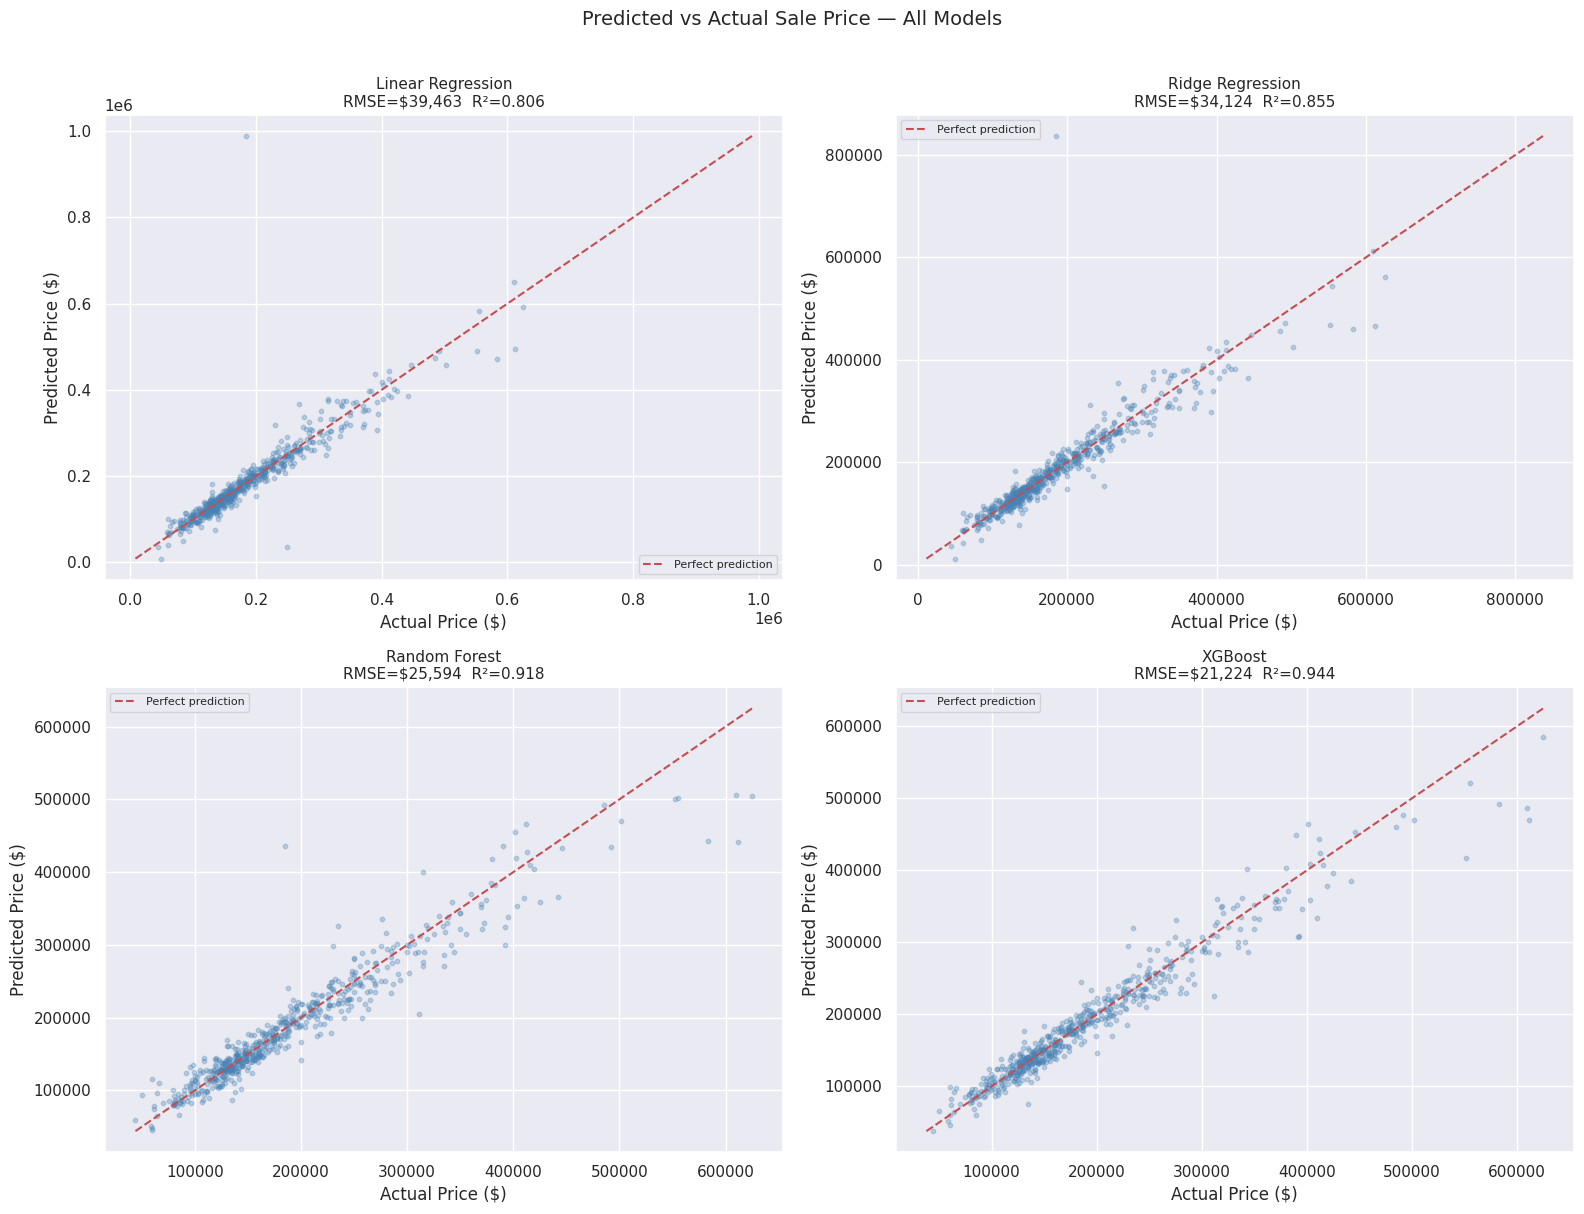

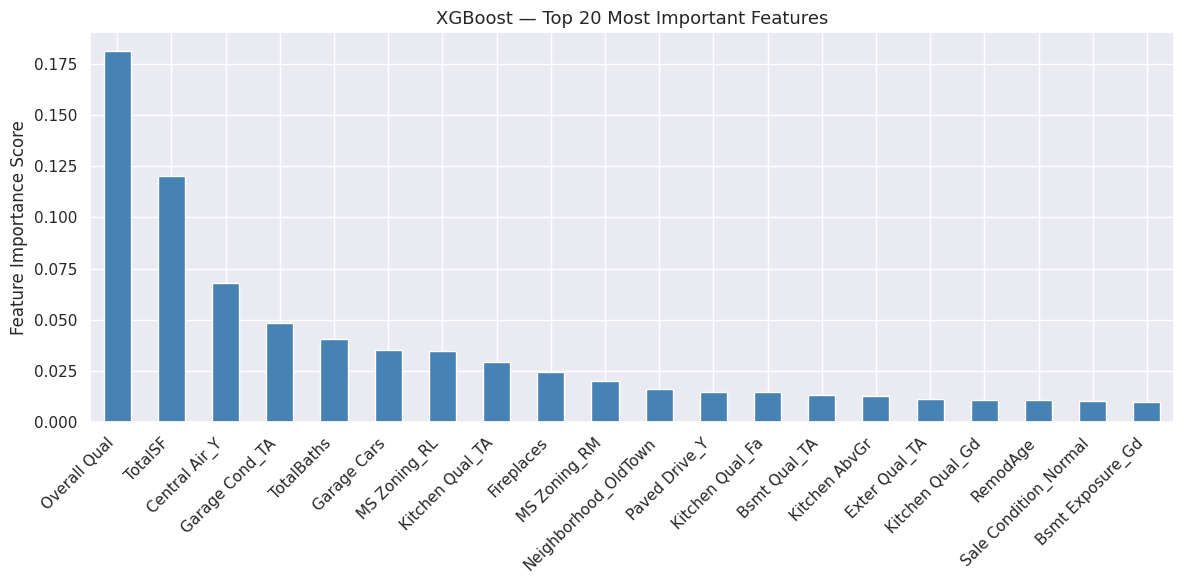

Top 20 features:
Overall Qual             0.1813
TotalSF                  0.1200
Central Air_Y            0.0682
Garage Cond_TA           0.0485
TotalBaths               0.0405
Garage Cars              0.0355
MS Zoning_RL             0.0347
Kitchen Qual_TA          0.0297
Fireplaces               0.0246
MS Zoning_RM             0.0203
Neighborhood_OldTown     0.0164
Paved Drive_Y            0.0149
Kitchen Qual_Fa          0.0147
Bsmt Qual_TA             0.0135
Kitchen AbvGr            0.0126
Exter Qual_TA            0.0116
Kitchen Qual_Gd          0.0107
RemodAge                 0.0107
Sale Condition_Normal    0.0105
Bsmt Exposure_Gd         0.0097
dtype: float32


In [13]:
# ── 8. Evaluation Plots ───────────────────────────────────────────────────

# predicted vs actual for each model — perfect model = all points on the diagonal
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_list = [
    ('Linear Regression', LinearRegression(),
     X_train_scaled, X_test_scaled),
    ('Ridge Regression',  Ridge(alpha=10),
     X_train_scaled, X_test_scaled),
    ('Random Forest',     RandomForestRegressor(n_estimators=200, random_state=42),
     X_train.values, X_test.values),
    ('XGBoost',           XGBRegressor(n_estimators=500, learning_rate=0.05,
                                       max_depth=4, random_state=42),
     X_train.values, X_test.values),
]

for ax, (name, model, X_tr, X_te) in zip(axes.flatten(), model_list):
    model.fit(X_tr, y_train)
    y_pred   = np.expm1(model.predict(X_te))
    y_actual = np.expm1(y_test)

    ax.scatter(y_actual, y_pred, alpha=0.3, s=10, color='steelblue')

    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5,
            label='Perfect prediction')

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)
    ax.set_title(f'{name}\nRMSE=${rmse:,.0f}  R²={r2:.3f}', fontsize=11)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Sale Price — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# XGBoost feature importance — how much each feature contributed across all trees
xgb_model  = model_list[3][1]
importance  = pd.Series(xgb_model.feature_importances_,
                         index=df_model.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importance.head(20).plot(kind='bar', color='steelblue')
plt.title('XGBoost — Top 20 Most Important Features', fontsize=13)
plt.ylabel('Feature Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 20 features:")
print(importance.head(20).round(4))

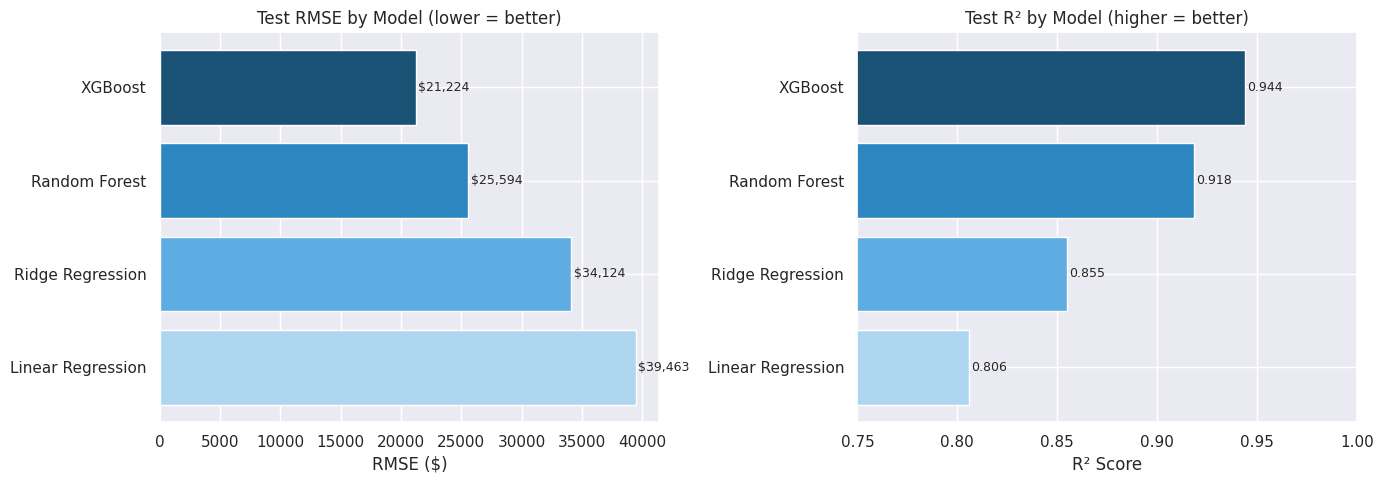

In [14]:
# ── 9. Final Comparison ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = results_df['Model']
colors      = ['#1a5276', '#2e86c1', '#5dade2', '#aed6f1']

axes[0].barh(model_names, results_df['RMSE'], color=colors)
axes[0].set_title('Test RMSE by Model (lower = better)', fontsize=12)
axes[0].set_xlabel('RMSE ($)')
axes[0].invert_yaxis()
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)

axes[1].barh(model_names, results_df['R2'], color=colors)
axes[1].set_title('Test R² by Model (higher = better)', fontsize=12)
axes[1].set_xlabel('R² Score')
axes[1].set_xlim(0.75, 1.0)
axes[1].invert_yaxis()
for i, v in enumerate(results_df['R2']):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# ── 10. Summary ───────────────────────────────────────────────────────────

print("=" * 55)
print("   HOUSE PRICE PREDICTION — FINAL SUMMARY")
print("=" * 55)
print("""
DATASET
  Source:    Ames Housing Dataset
  Houses:    2,930
  Features:  80 original → 270 after encoding
  Target:    Log(SalePrice) — converted back to $ for evaluation
""")
print("─" * 55)
print("FEATURE ENGINEERING")
print("""
  Created 6 new features from existing columns:
  TotalSF      — basement + 1st + 2nd floor area combined
  TotalBaths   — all bathrooms weighted (half baths = 0.5)
  HouseAge     — years from build to sale
  RemodAge     — years from last remodel to sale
  WasRemodeled — binary flag
  IsNew        — binary flag for brand new houses

  TotalSF became the 2nd most important feature (12.0%)
  TotalBaths ranked 5th (4.1%) — engineering paid off
""")
print("─" * 55)
print("MODEL RESULTS")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<20} RMSE=${row['RMSE']:>8,.0f}   R²={row['R2']:.3f}")
print("""
  Best model: XGBoost
  On a median-priced house ($160,000) an average
  error of $21,224 represents ~13% error rate
""")
print("─" * 55)
print("KEY FINDINGS")
print("""
  1. Overall quality rating is the single strongest
     predictor (r=0.83, importance=18.1%)

  2. Size features dominate — TotalSF, Garage Area,
     Basement SF collectively explain ~25% of variance

  3. Neighborhood adds significant value — StoneBr
     median ($319k) is 3.6x higher than MeadowV ($88k)

  4. Tree-based models outperform linear models
     significantly — house prices have non-linear
     relationships that linear regression can't capture

  5. Log-transforming the target reduced skewness
     from 1.744 to -0.015, improving all model scores
""")
print("=" * 55)

   HOUSE PRICE PREDICTION — FINAL SUMMARY

DATASET
  Source:    Ames Housing Dataset
  Houses:    2,930
  Features:  80 original → 270 after encoding
  Target:    Log(SalePrice) — converted back to $ for evaluation

───────────────────────────────────────────────────────
FEATURE ENGINEERING

  Created 6 new features from existing columns:
  TotalSF      — basement + 1st + 2nd floor area combined
  TotalBaths   — all bathrooms weighted (half baths = 0.5)
  HouseAge     — years from build to sale
  RemodAge     — years from last remodel to sale
  WasRemodeled — binary flag
  IsNew        — binary flag for brand new houses
 
  TotalSF became the 2nd most important feature (12.0%)
  TotalBaths ranked 5th (4.1%) — engineering paid off

───────────────────────────────────────────────────────
MODEL RESULTS
  XGBoost              RMSE=$  21,224   R²=0.944
  Random Forest        RMSE=$  25,594   R²=0.918
  Ridge Regression     RMSE=$  34,124   R²=0.855
  Linear Regression    RMSE=$  39,463   R²